# 02 — Data Understanding
**Project:** Climate-Driven Solar Energy Analytics  
**Goal:** Deep-dive into a single city's dataset — structure, statistics, distributions, and correlations.

---
### Why single-city first?
Before comparing 15 cities, we must fully understand what *one* dataset looks like.  
We use **Bengaluru** as the representative city. Every pattern found here will guide our
multi-city analysis in notebook 04.

We answer four questions in order:
1. What does the data look like structurally? (shape, columns, types)
2. Is the data clean? (nulls, out-of-range values)
3. What do the numbers tell us? (descriptive statistics)
4. Which features are related to our target? (correlation)

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Consistent visual style across the whole project
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

TARGET = "ALLSKY_SFC_SW_DWN"
CITY   = "Bengaluru"

---
## 1 · Load & Structural Overview

In [2]:
df = pd.read_csv(f"../data/raw/{CITY}.csv", skiprows=17)

# ── Create a proper datetime index immediately ─────────────────────────────
# Why? It lets us use time-based slicing, resampling, and plotting correctly.
df["DATE"] = pd.to_datetime({
    "year":  df["YEAR"],
    "month": df["MO"],
    "day":   df["DY"]
})
df = df.set_index("DATE")

print(f"City   : {CITY}")
print(f"Shape  : {df.shape}  →  {df.shape[0]} days × {df.shape[1]} features")
print(f"Period : {df.index.min().date()}  to  {df.index.max().date()}")
print()
df.head()

City   : Bengaluru
Shape  : (2192, 12)  →  2192 days × 12 features
Period : 2019-01-01  to  2024-12-31



,YEAR,MO,DY,T2M,T2M_MAX,T2M_MIN,RH2M,PS,WS10M,CLOUD_AMT,PRECTOTCORR,ALLSKY_SFC_SW_DWN
DATE,,,,,,,,,,,,
2019-01-01,2019,1,1,19.39,30.31,10.27,47.59,92.24,3.79,12.78,0.0,6.0528
2019-01-02,2019,1,2,19.22,30.30,9.86,49.99,92.25,4.26,11.46,0.0,6.0701
2019-01-03,2019,1,3,19.63,30.61,11.18,49.04,92.30,4.09,12.97,0.0,6.0120
2019-01-04,2019,1,4,19.57,29.92,10.35,51.83,92.24,4.66,11.34,0.0,6.0348
2019-01-05,2019,1,5,19.89,31.27,10.88,52.66,92.12,3.56,9.76,0.0,6.1406


In [3]:
# ── Data Types ─────────────────────────────────────────────────────────────
# All features should be numeric. int64 for YEAR/MO/DY, float64 for the rest.
# Non-numeric types here would indicate a parsing problem.
print("Column data types:")
print(df.dtypes)

Column data types:
YEAR                   int64
MO                     int64
DY                     int64
T2M                  float64
T2M_MAX              float64
T2M_MIN              float64
RH2M                 float64
PS                   float64
WS10M                float64
CLOUD_AMT            float64
PRECTOTCORR          float64
ALLSKY_SFC_SW_DWN    float64
dtype: object


---
## 2 · Data Quality Check
We check for:
- **Null values** — if any feature has NaN, we need an imputation strategy before ML.
- **Physical plausibility** — e.g. solar radiation can't be negative, humidity can't exceed 100 %.
- **Duplicate rows** — two records for the same date would distort aggregations.

In [4]:
# ── Null check ────────────────────────────────────────────────────────────
nulls = df.isnull().sum()
print("Null values per column:")
print(nulls)

# ── Duplicate dates ───────────────────────────────────────────────────────
dups = df.index.duplicated().sum()
print(f"\nDuplicate date rows : {dups}")

# ── Physical range checks ─────────────────────────────────────────────────
BOUNDS = {
    "RH2M"             : (0, 100),     # relative humidity %
    "CLOUD_AMT"        : (0, 100),     # cloud amount %
    TARGET             : (0, None),    # solar radiation >= 0
    "PRECTOTCORR"      : (0, None),    # rainfall >= 0
}

print("\nPhysical range violations:")
any_violation = False
for col, (lo, hi) in BOUNDS.items():
    if col not in df.columns:
        continue
    below = (df[col] < lo).sum() if lo is not None else 0
    above = (df[col] > hi).sum() if hi is not None else 0
    if below + above > 0:
        print(f"  ⚠️  {col}: {below} below {lo}, {above} above {hi}")
        any_violation = True
if not any_violation:
    print("  ✅ No violations found.")

Null values per column:
YEAR                 0
MO                   0
DY                   0
T2M                  0
T2M_MAX              0
T2M_MIN              0
RH2M                 0
PS                   0
WS10M                0
CLOUD_AMT            0
PRECTOTCORR          0
ALLSKY_SFC_SW_DWN    0
dtype: int64

Duplicate date rows : 0

Physical range violations:
  ✅ No violations found.


---
## 3 · Descriptive Statistics
Summary statistics tell us the **central tendency** (mean, median) and **spread** (std, IQR) of each variable.  
Together they reveal whether features have similar scales — important for algorithms like
Linear Regression and KNN that are distance-sensitive and will need normalisation later.

In [5]:
FEATURE_COLS = ["T2M", "T2M_MAX", "T2M_MIN", "RH2M", "PS",
                "WS10M", "CLOUD_AMT", "PRECTOTCORR", TARGET]

stats = df[FEATURE_COLS].describe().round(3).T

# Add IQR (25th–75th percentile range) — a robust measure of spread
stats["IQR"] = (stats["75%"] - stats["25%"]).round(3)

print(stats)

                    count    mean     std     min     25%     50%     75%  \
T2M                2192.0  23.929   2.764  16.620  22.140  23.430  25.540   
T2M_MAX            2192.0  30.207   3.788  20.690  27.200  29.420  32.820   
T2M_MIN            2192.0  18.849   2.608   9.220  17.560  19.450  20.470   
RH2M               2192.0  70.196  16.058  23.990  59.175  75.300  83.110   
PS                 2192.0  91.673   0.236  91.000  91.500  91.660  91.850   
WS10M              2192.0   3.937   1.496   0.920   2.870   3.715   4.720   
CLOUD_AMT          2192.0  62.417  33.278   0.040  32.918  71.465  94.205   
PRECTOTCORR        2192.0   2.865   7.837   0.000   0.000   0.180   2.750   
ALLSKY_SFC_SW_DWN  2192.0   5.272   1.250   0.908   4.430   5.368   6.167   

                       max     IQR  
T2M                 32.380   3.400  
T2M_MAX             40.780   5.620  
T2M_MIN             27.190   2.910  
RH2M                95.420  23.935  
PS                  92.310   0.350  
WS10M  

---
## 4 · Solar Radiation Time Series
A raw daily time-series is noisy. Plotting a **30-day rolling mean** alongside the raw values
reveals the seasonal trend without losing day-to-day variability.

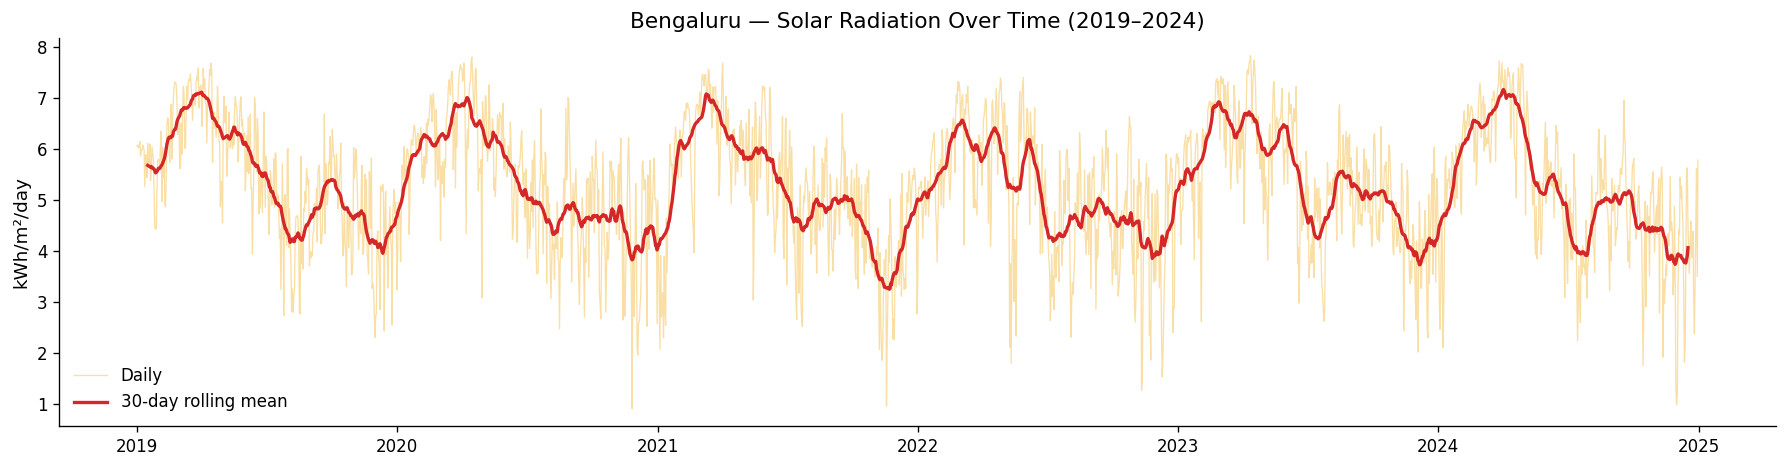


Interpretation:
  • The recurring peaks (Mar–Apr) and troughs (Jul–Aug, Dec) confirm a clear seasonal cycle.
  • The rolling mean is the signal; daily values are signal + noise.
  • This seasonality is a key reason MONTH will be a powerful engineered feature in Phase 5.



In [6]:
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(df.index, df[TARGET],
        color="#f0a500", alpha=0.35, linewidth=0.8, label="Daily")

rolling = df[TARGET].rolling(30, center=True).mean()
ax.plot(df.index, rolling,
        color="#d62728", linewidth=2, label="30-day rolling mean")

ax.set_title(f"{CITY} — Solar Radiation Over Time (2019–2024)")
ax.set_ylabel("kWh/m²/day")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  • The recurring peaks (Mar–Apr) and troughs (Jul–Aug, Dec) confirm a clear seasonal cycle.
  • The rolling mean is the signal; daily values are signal + noise.
  • This seasonality is a key reason MONTH will be a powerful engineered feature in Phase 5.
""")

---
## 5 · Feature Distributions
A histogram + KDE (kernel density estimate) for every feature tells us:
- Is the feature **normally distributed** (bell-shaped)? Many ML models prefer this.
- Is it **skewed**? Rainfall typically has a right-skew (many zero/low days, rare heavy events).
- Are there **bimodal** patterns suggesting distinct climate regimes?

This informs whether we'll need log-transforms or scaling in Phase 5.

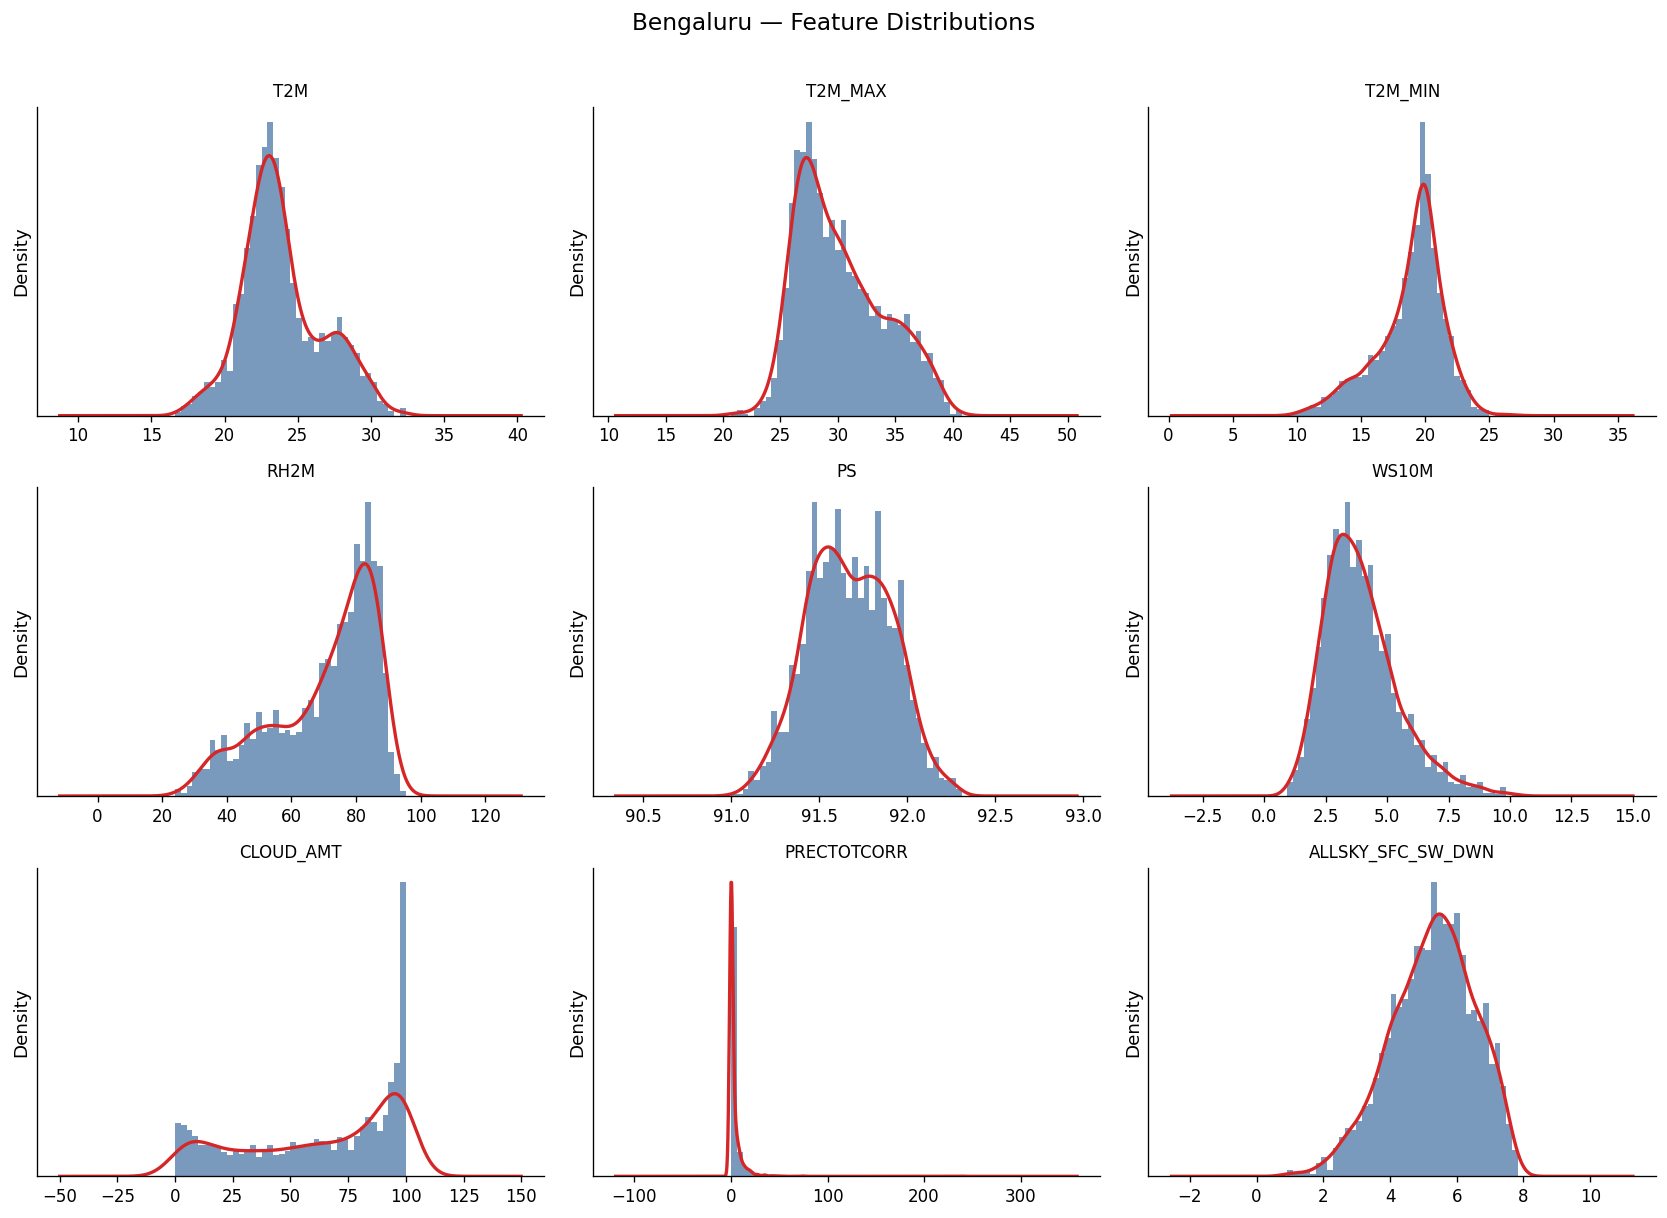

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for ax, col in zip(axes.flat, FEATURE_COLS):
    ax.hist(df[col], bins=40, color="#4e79a7", edgecolor="none", alpha=0.75, density=True)
    df[col].plot.kde(ax=ax, color="#d62728", linewidth=2)
    ax.set_title(col, fontsize=10)
    ax.set_yticks([])

fig.suptitle(f"{CITY} — Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 6 · Correlation Analysis
Pearson correlation measures the **linear relationship** between two variables.
- Values near +1 → strong positive relationship
- Values near −1 → strong negative relationship  
- Values near 0 → no linear relationship

Important caveat: correlation ≠ causation.  
High temperature *correlates with* more solar radiation because both peak in summer — but temperature doesn't *cause* it; the Sun's position causes both.

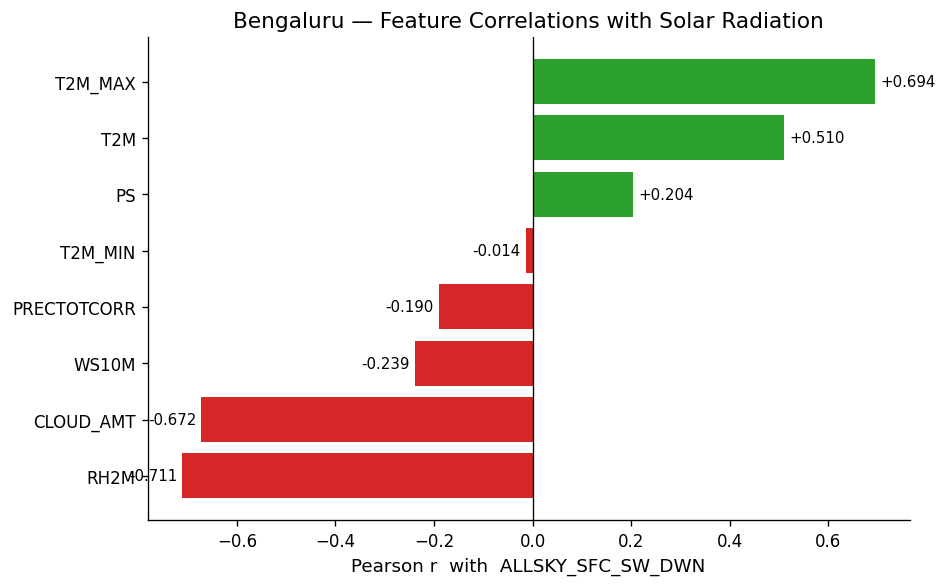


Key findings:
  🟢 T2M_MAX  (+0.69)  → Hot days tend to be clearer → more solar energy
  🟢 T2M      (+0.51)  → Same reason as above
  🔴 RH2M     (−0.71)  → High humidity = cloud/haze = less radiation reaching ground
  🔴 CLOUD_AMT(−0.67)  → Direct blocking of sunlight
  🔴 WS10M    (−0.24)  → Stronger winds associated with weather systems



In [8]:
corr_series = (
    df[FEATURE_COLS]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values()
)

colors = ["#d62728" if v < 0 else "#2ca02c" for v in corr_series]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(corr_series.index, corr_series.values, color=colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Pearson r  with  {TARGET}")
ax.set_title(f"{CITY} — Feature Correlations with Solar Radiation")

for bar, val in zip(bars, corr_series.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

print("""
Key findings:
  🟢 T2M_MAX  (+0.69)  → Hot days tend to be clearer → more solar energy
  🟢 T2M      (+0.51)  → Same reason as above
  🔴 RH2M     (−0.71)  → High humidity = cloud/haze = less radiation reaching ground
  🔴 CLOUD_AMT(−0.67)  → Direct blocking of sunlight
  🔴 WS10M    (−0.24)  → Stronger winds associated with weather systems
""")

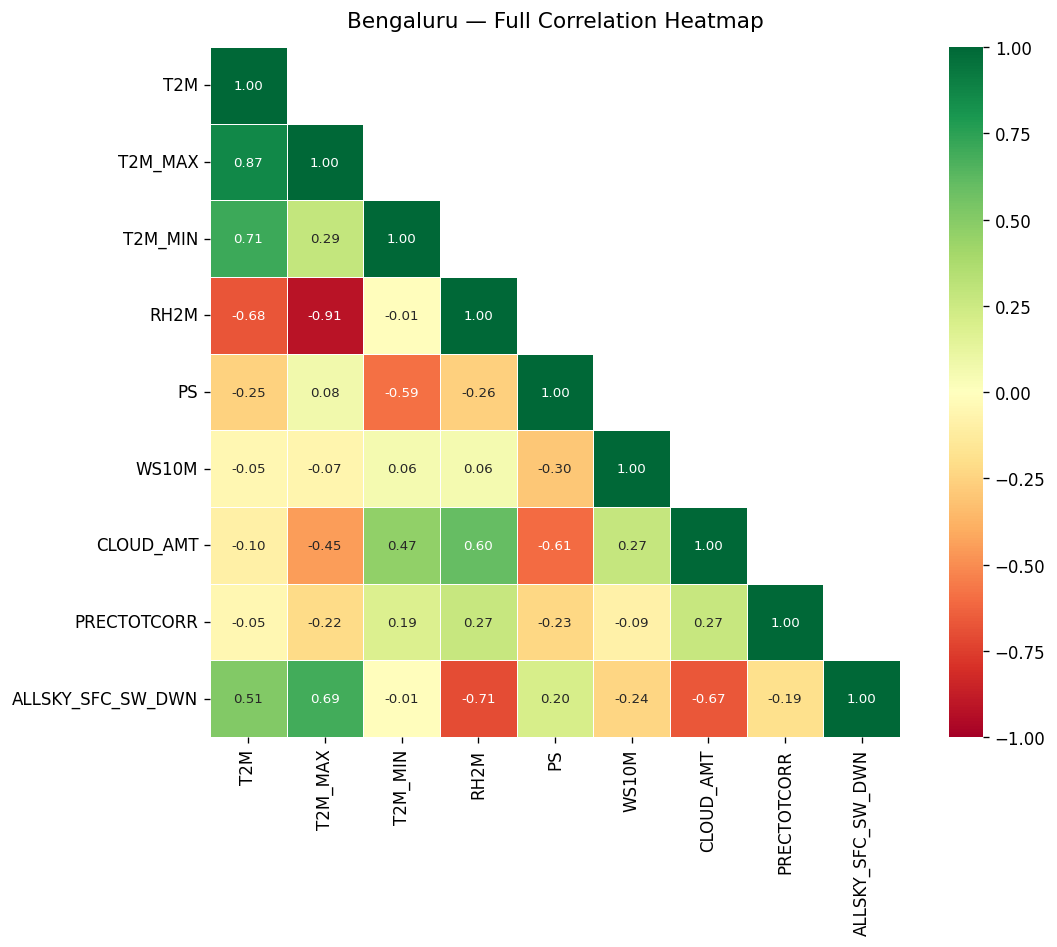


Watch for multicollinearity:
  T2M ↔ T2M_MAX ↔ T2M_MIN are all temperature variants — expect high mutual correlation.
  We may need to drop or combine them in Phase 5 feature engineering.



In [9]:
# Full correlation heatmap — see how ALL features relate to each other
# This is especially useful to detect multicollinearity:
# e.g. T2M and T2M_MAX are highly correlated → including both in a model
# can inflate regression coefficients (variance inflation).

corr_matrix = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)
# mask upper triangle to avoid redundancy
import numpy as np
mask_arr = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1, square=True,
    mask=mask_arr, linewidths=0.5, ax=ax,
    annot_kws={"size": 8}
)
ax.set_title(f"{CITY} — Full Correlation Heatmap", pad=12)
plt.tight_layout()
plt.show()

print("""
Watch for multicollinearity:
  T2M ↔ T2M_MAX ↔ T2M_MIN are all temperature variants — expect high mutual correlation.
  We may need to drop or combine them in Phase 5 feature engineering.
""")

---
## ✅ Data Understanding Summary

| Finding | Detail |
|---------|--------|
| Data quality | No nulls, no duplicates, all values physically plausible |
| Strong positive predictors | T2M_MAX (+0.69), T2M (+0.51) |
| Strong negative predictors | RH2M (−0.71), CLOUD_AMT (−0.67) |
| Weak predictor | PRECTOTCORR (−0.19), DY (+0.05) |
| Multicollinearity risk | T2M, T2M_MAX, T2M_MIN are all temperature-based |
| Skewed feature | PRECTOTCORR (right-skewed) → log-transform may help |
| Seasonality | Strong annual cycle; MONTH will be an important engineered feature |

**Next notebook →** `03_seasonal_analysis.ipynb` — monthly patterns and season labelling.